In [3]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import matplotlib.pyplot as plt  # 用于数据可视化
import mplfinance as mpf  # 用于绘制金融图表
from matplotlib import style
from dataclasses import dataclass
from important_point_algorithm import rw_top,rw_bottom,rw_extremes,directional_change,get_extremes,find_pips
    # 绘制牛市旗形的性能图表

# 加载数据
# 从Excel文件中读取上证指数数据
data = pd.read_excel('C:/Users/Amber/Desktop/2025年策略Task/PA量化/旗形形态/【pip】上证指数旗形运行结果/不同order结果/上证指数数据.xlsx')
data = data.set_index('Date')  # 将Date列设置为索引

# 对价格取对数
# 对除Change列外的所有列取对数
# 将日期索引转换为DatetimeIndex格式
data.index = pd.to_datetime(data.index).copy()

# 只对Close、High、Low列取对数
for col in ['Close', 'High', 'Low']:
    if col in data.columns:
        data[col] = np.log(data[col]).copy()

# 提取收盘价和成交量数据
dat_slice = data[['Close', 'Volume']].to_numpy().copy()


In [4]:
# 查看dat_slice的类型和结构
print("数据类型:", type(dat_slice))
print("数据形状:", dat_slice.shape)

# 在NumPy数组中，没有直接的index属性
# dat_slice是一个NumPy数组，它使用整数索引从0开始
# 如果需要获取原始DataFrame的索引，应该使用data.index
print("原始DataFrame的索引类型:", type(data.index))
print("原始DataFrame的索引示例:", data.index[:5])  # 显示前5个索引值

数据类型: <class 'numpy.ndarray'>
数据形状: (7320, 2)
原始DataFrame的索引类型: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
原始DataFrame的索引示例: DatetimeIndex(['1995-01-03', '1995-01-04', '1995-01-05', '1995-01-06',
               '1995-01-09'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [5]:
# 这是Python的一个装饰器,用来简化类的定义。它会自动帮我们生成__init__()等基础方法,让我们只需要定义类的属性就可以了,不用写很多重复的代码。
#__init__()是类的构造函数,当我们创建类的实例时会自动调用它来初始化实例的属性。比如定义一个普通的类需要写构造函数,而用@dataclass就不用写了。
@dataclass  
class FlagPattern:  # 定义一个旗形模式类,用于存储和表示股票价格中的旗形形态特征
    """
    这是一个使用Python的dataclass装饰器定义的类，用于表示旗形和三角旗形态。
    @dataclass是Python的一个装饰器，它会自动为类生成特殊方法，如__init__、__repr__等，
    简化了数据类的创建过程，使代码更加简洁。
    """

    # 旗形和三角旗形态的数据结构
    
    # 属性:
    base_x: int         # 趋势起点索引，旗杆的底部
    base_y: float       # 趋势起点价格
    
    tip_x: int   = -1       # 旗杆顶部/底部索引，旗帜开始点。初始化为-1表示尚未找到有效的旗杆顶部/底部点
    tip_y: float = -1.      # 旗杆顶部/底部价格。初始化为-1表示尚未找到有效的价格点
    
    conf_x: int   = -1      # 形态确认点索引（突破点）
    conf_y: float = -1.     # 形态确认点价格
    
    pennant: bool = False   # True表示三角旗，False表示旗形
    
    flag_width: int    = -1    # 旗帜宽度（时间跨度）
    flag_height: float = -1.   # 旗帜高度（价格跨度）
    
    pole_width: int    = -1    # 旗杆宽度（时间跨度）
    pole_height: float = -1.   # 旗杆高度（价格跨度）
    
    # 旗帜的上下趋势线，截距在旗杆顶部/底部
    support_intercept: float = -1.  # 支撑线截距
    support_slope: float = -1.      # 支撑线斜率
    resist_intercept: float = -1.   # 阻力线截距
    resist_slope: float = -1.       # 阻力线斜率

    # 新增成交量相关属性
    avg_flag_volume: float = -1.  # 旗帜区间的平均成交量
    breakout_volume: float = -1.  # 突破时的成交量
    volume_ratio: float = -1.     # 突破成交量/平均成交量的比率


def check_bear_pattern_pips(pending: FlagPattern, data: np.array, i: int, order: int, volume: np.array = None):
    """
    检查熊市旗形/三角旗形态（基于PIP点方法）
    
    参数:
    pending: FlagPattern - 待填充的旗形对象
    data: np.array - 价格数据数组
    i: int - 当前检查的索引位置
    order: int - 滚动窗口大小参数
    
    返回:
    bool - 如果识别到有效形态则返回True，否则返回False
    """

    # 找出自局部顶部以来的最低价格（旗杆底部）
    # 从旗杆底部(pending.base_x)到当前检查位置(i)的数据切片
    # data[pending.base_x: i + 1]表示取数据从旗杆底部到当前位置的子集
    # i+1是因为在Python中切片的右边界是开区间,即不包含i+1这个位置
    
    # pending.base_x是旗杆底部的索引位置
    # 这行代码从旗杆底部(pending.base_x)到当前检查位置(i)提取了一段数据
    # i+1是因为切片右边界是开区间,所以需要+1才能包含i这个位置
    data_slice = data[pending.base_x: i + 1]  
    
    # 切片(slice)是从数组中提取一段连续数据的操作
    # 例如data_slice = data[pending.base_x: i + 1]就是一个切片操作
    # 它从原始数组data中提取了从pending.base_x到i的这一段数据
    # argmin()返回切片中最小值的索引位置
    # 由于切片是原始数组的一部分,所以需要加上切片起点pending.base_x才是在原始数组中的实际位置
    min_i = data_slice.argmin() + pending.base_x  # 自局部顶部以来的最低点索引
    
    # 确保从最低点到当前位置有足够的距离来形成旗帜
    if i - min_i < max(5, order * 0.5):  # 这行代码检查当前位置i到最低点min_i的距离是否小于两个值中的较大值:
                                         # 1. 固定值5
                                         # 2. order参数的一半
                                         # 如果距离太小,说明还没有形成足够宽的旗形形态,返回False
        return False
    
    # 测试旗帜宽度/高度
    pole_width = min_i - pending.base_x  # 旗杆宽度
    flag_width = i - min_i  # 旗帜宽度
    # 旗帜宽度应小于旗杆宽度的一半
    if flag_width > pole_width * 0.5:
        return False

    pole_height = pending.base_y - data[min_i]  # 旗杆高度
    flag_height = data[min_i:i+1].max() - data[min_i]  # 旗帜高度
    # 旗帜高度应小于旗杆高度的一半
    if flag_height > pole_height * 0.5:
        return False

    # 到这里，宽度/高度检查通过
    
    # 找出旗帜部分的感知重要点(PIP)
    # 找出从最低点到当前索引之间的5个PIP点
    # 5表示要找出5个重要点位(PIP点)

    pips_x, pips_y = find_pips(data[min_i:i+1], 5, 3)

    # 检查中心PIP点是否低于相邻的两个点，形成/\/\形状
    if not (pips_y[2] < pips_y[1] and pips_y[2] < pips_y[3]):
        return False
    
    # 计算旗帜的支撑线和阻力线
    # 支撑线：连接第1个和第3个PIP点
    support_rise = pips_y[2] - pips_y[0]  # 支撑线上升高度
    support_run = pips_x[2] - pips_x[0]  # 支撑线水平距离
    support_slope = support_rise / support_run  # 支撑线斜率
    support_intercept = pips_y[0]  # 支撑线截距
    
    # 阻力线：连接第2个和第4个PIP点
    resist_rise = pips_y[3] - pips_y[1]  # 阻力线上升高度
    resist_run = pips_x[3] - pips_x[1]  # 阻力线水平距离
    resist_slope = resist_rise / resist_run  # 阻力线斜率
    resist_intercept = pips_y[1] + (pips_x[0] - pips_x[1]) * resist_slope  # 阻力线截距

    # 计算两条线的交点
    if resist_slope != support_slope:  # 非平行线
        intersection = (support_intercept - resist_intercept) / (resist_slope - support_slope)
    else:
        intersection = -flag_width * 100  # 平行线，设置一个远离旗帜区域的交点

    # 如果交点在旗帜区域内，则不是有效的旗形/三角旗
    if intersection <= pips_x[4] and intersection >= 0:
        return False

    # 检查当前点是否突破旗帜下边界（支撑线），确认形态
    support_endpoint = pips_y[0] + support_slope * pips_x[4]
    if pips_y[4] > support_endpoint:  # 如果价格高于支撑线，则未突破
        return False
    
    flag_start = min_i  # 旗帜开始点
    flag_volumes = volume[flag_start:i+1]
    avg_flag_volume = np.mean(flag_volumes)
    
    # 确认点的成交量应大于旗帜区域的平均成交量
    if volume[i] <= avg_flag_volume:
        return False  # 成交量不足，不确认突破
    
    # 判断是旗形还是三角旗
    # 如果阻力线向下倾斜（斜率为负），则为三角旗
    if resist_slope < 0:
        pending.pennant = True
    else:
        pending.pennant = False
    
    # 过滤严重发散的线（交点太近）
    if intersection < 0 and intersection > -flag_width:
        return False

    # 形态确认，填充旗形对象的属性
    pending.tip_x = min_i  # 旗杆底部索引
    pending.tip_y = data[min_i]  # 旗杆底部价格
    pending.conf_x = i  # 确认点索引
    pending.conf_y = data[i]  # 确认点价格
    # 保存成交量信息到旗形对象
    pending.avg_flag_volume = avg_flag_volume
    pending.breakout_volume = float(volume[i])
    pending.volume_ratio = float(volume[i]) / avg_flag_volume
    pending.flag_width = flag_width  # 旗帜宽度
    pending.flag_height = flag_height  # 旗帜高度
    pending.pole_width = pole_width  # 旗杆宽度
    pending.pole_height = pole_height  # 旗杆高度
    pending.support_slope = support_slope  # 支撑线斜率
    pending.support_intercept = support_intercept  # 支撑线截距
    pending.resist_slope = resist_slope  # 阻力线斜率
    pending.resist_intercept = resist_intercept  # 阻力线截距
    
    return True  # 返回True表示识别到有效形态
    

def check_bull_pattern_pips(pending: FlagPattern, data: np.array, i:int, order:int, volume: np.array = None):
    """
    检查牛市旗形/三角旗形态（基于PIP点方法），可选结合成交量确认
    
    参数:
    pending: FlagPattern - 待填充的旗形对象
    data: np.array - 价格数据数组(一维)
    i: int - 当前检查的索引位置
    order: int - 滚动窗口大小参数
    volume_data: np.array - 可选的成交量数据数组(一维)
    
    返回:
    bool - 如果识别到有效形态则返回True，否则返回False
    """

    # 找出自局部底部以来的最高价格（旗杆顶部）
    # 这行代码从价格数组data中提取了从pending.base_x（局部底部）到i+1（当前位置）的一段数据。i+1是为了包含当前价格点，因为Python切片是左闭右开的。
    data_slice = data[pending.base_x: i + 1]  # i + 1包含当前价格

    # 这行代码在寻找从局部底部到当前位置之间的最高价格点的索引。
    # data_slice.argmax()找到切片中最高价格的位置，加上pending.base_x是为了将这个相对位置转换为在原始数组中的绝对位置。这个索引将用于确定旗杆的顶部位置。
    max_i = data_slice.argmax() + pending.base_x  # 自局部底部以来的最高点索引
    pole_width = max_i - pending.base_x  # 旗杆宽度
    
    # 确保从最高点到当前位置有足够的距离来形成旗帜
    if i - max_i < max(5, order * 0.5):
        return False

    # 测试旗帜宽度/高度
    flag_width = i - max_i  # 旗帜宽度
    # 旗帜宽度应小于旗杆宽度的一半
    if flag_width > pole_width * 0.5:
        return False

    pole_height = data[max_i] - pending.base_y  # 旗杆高度
    flag_height = data[max_i] - data[max_i:i+1].min()  # 旗帜高度
    # 旗帜高度应小于旗杆高度的一半
    if flag_height > pole_height * 0.5:
        return False

    # 找出旗帜部分的感知重要点(PIP)
    # 找出从最高点到当前索引之间的5个PIP点
    # pips_y[0]是第一个PIP点的价格,代表旗帜区域的起始点
    # pips_y[4]是最后一个PIP点的价格,代表当前价格点
    pips_x, pips_y = find_pips(data[max_i:i+1], 5, 3)  

    # 检查中心PIP点是否高于相邻的两个点，形成\/\/形状
    if not (pips_y[2] > pips_y[1] and pips_y[2] > pips_y[3]):
        return False
        
    # 计算旗帜的阻力线和支撑线
    # 阻力线：连接第1个和第3个PIP点
    # 计算阻力线的上升高度，即第3个PIP点(pips_y[2])与第1个PIP点(pips_y[0])的垂直距离
    resist_rise = pips_y[2] - pips_y[0]  # 阻力线上升高度
    
    # 计算阻力线的水平距离，即第3个PIP点(pips_x[2])与第1个PIP点(pips_x[0])的水平距离
    resist_run = pips_x[2] - pips_x[0]  # 阻力线水平距离
    
    # 计算阻力线的斜率，使用上升高度除以水平距离
    # 斜率为正表示向上倾斜，为负表示向下倾斜
    resist_slope = resist_rise / resist_run  # 阻力线斜率
    
    # 计算阻力线的截距，即阻力线与y轴的交点
    # 这里直接使用第1个PIP点的y值作为截距
    resist_intercept = pips_y[0]  # 阻力线截距

    # 支撑线：连接第2个和第4个PIP点
    support_rise = pips_y[3] - pips_y[1]  # 支撑线上升高度
    support_run = pips_x[3] - pips_x[1]  # 支撑线水平距离
    support_slope = support_rise / support_run  # 支撑线斜率
    support_intercept = pips_y[1] + (pips_x[0] - pips_x[1]) * support_slope  # 支撑线截距

    # 计算两条线的交点
    if resist_slope != support_slope:  # 非平行线
        # 计算支撑线和阻力线的交点的x坐标
        # 使用两条直线方程联立求解:
        # y = resist_slope * x + resist_intercept
        # y = support_slope * x + support_intercept
        # 解出x坐标(intersection)
        intersection = (support_intercept - resist_intercept) / (resist_slope - support_slope)
    else:
        # 当支撑线和阻力线平行时,将交点设置在旗帜区域左侧很远的位置
        # 这样做是为了确保交点不会落在旗帜区域内
        # flag_width是旗帜的宽度,乘以100是为了将交点设得足够远
        intersection = -flag_width * 100  # 平行线，设置一个远离旗帜区域的交点

    # 如果交点在旗帜区域内，则不是有效的旗形/三角旗
    # 因为有效的旗形/三角旗的支撑线和阻力线应该在旗帜区域外相交
    # 如果在旗帜区域内相交，说明两条趋势线收敛太快，形成的是一个楔形形态而不是旗形
    # 楔形形态通常代表趋势的延续或反转，而旗形则代表趋势的暂时休整
    if intersection <= pips_x[4] and intersection >= 0:
        return False
    
    # 过滤严重发散的线（交点太近）
    # 如果交点在旗帜宽度的负1倍范围内,说明两条趋势线发散得太快,不是有效形态
    # 例如:如果旗帜宽度为10,那么交点应该在x<-10的位置,否则说明趋势线发散太快
    if intersection < 0 and intersection > -1.0 * flag_width:
        return False

    # 检查当前点是否突破旗帜上边界（阻力线），确认形态
    resist_endpoint = pips_y[0] + resist_slope * pips_x[4]
    if pips_y[4] < resist_endpoint:  # 如果价格低于阻力线，则未突破
        return False
    
    flag_start = max_i  # 旗帜开始点
    flag_volumes = volume[flag_start:i+1]
    avg_flag_volume = np.mean(flag_volumes)
    
    # 确认点的成交量应大于旗帜区域的平均成交量
    if volume[i] <= avg_flag_volume:
        return False  # 成交量不足，不确认突破


    # 判断是旗形还是三角旗
    # 如果支撑线向上倾斜（斜率为正），则为三角旗
    if support_slope > 0:
        pending.pennant = True
    else:
        pending.pennant = False

    # 形态确认，填充旗形对象的属性
    pending.tip_x = max_i  # 旗杆顶部索引
    pending.tip_y = data[max_i]  # 旗杆顶部价格
    pending.conf_x = i  # 确认点索引
    pending.conf_y = data[i]  # 确认点价格
    # 保存成交量信息到旗形对象
    pending.avg_flag_volume = avg_flag_volume
    pending.breakout_volume = float(volume[i])
    pending.volume_ratio = float(volume[i]) / avg_flag_volume
    pending.flag_width = flag_width  # 旗帜宽度
    pending.flag_height = flag_height  # 旗帜高度
    pending.pole_width = pole_width  # 旗杆宽度
    pending.pole_height = pole_height  # 旗杆高度
    
    pending.support_slope = support_slope  # 支撑线斜率
    pending.support_intercept = support_intercept  # 支撑线截距

    pending.resist_slope = resist_slope  # 阻力线斜率
    pending.resist_intercept = resist_intercept  # 阻力线截距
    
    return True  # 返回True表示识别到有效形态


def find_flags_pennants_pips(data: np.array, order: int, volume: np.array = None):
    """
    基于PIP点方法识别旗形和三角旗形态，可选结合成交量确认
    
    参数:
    data: np.array - 价格数据数组(一维)
    order: int - 滚动窗口大小参数
    volume: np.array - 可选的成交量数据数组(一维)
    
    返回:
    bull_flags, bear_flags, bull_pennants, bear_pennants
    """
    assert(order >= 3)  # 确保窗口大小参数至少为3
    assert(data.ndim == 1), "价格数据必须是一维数组"
    if volume is not None:
        assert(volume.ndim == 1), "成交量数据必须是一维数组"
        assert(len(volume) == len(data)), "成交量数据长度必须与价格数据相同"
    
    
    pending_bull = None  # 待处理的牛市形态
    pending_bear = None  # 待处理的熊市形态

    # 初始化结果列表
    bull_pennants = []  # 牛市三角旗列表
    bear_pennants = []  # 熊市三角旗列表
    bull_flags = []     # 牛市旗形列表
    bear_flags = []     # 熊市旗形列表
    
    '''
    因为：
    熊旗形态是从高点开始向下运动，所以需要从局部高点开始寻找
    牛旗形态是从低点开始向上运动，所以需要从局部低点开始寻找
    这符合市场趋势的基本原理 - 熊市从高点下跌，牛市从低点上涨。
        
    '''

    # 遍历价格数据 len(data)返回7320，而range()函数生成的序列是从0开始到结束值-1，所以i的取值范围是0到7319。这与数据帧的7320行数据相对应。
    for i in range(len(data)):# range(len(data))的取值范围是从0到7319，因为根据上下文中的数据帧输出显示总共有7320行数据（[7320 rows x 6 columns]）。

        # 识别局部极值点作为形态起点
        '''
        rw_top(data, i, order)函数会检查i-order位置的点是否是在[i-2*order, i]这个窗口范围内的局部高点。
        也就是说，它需要等待后续order个点的数据才能确认i-order位置是否真的是局部高点。
        这样设计是为了避免在实时分析中的"提前预知"问题。
        '''
        if rw_top(data, i, order):   # 如果是局部高点，i是当前遍历到的数据点的索引，order参数为12，表示在前后各12个点(共25个点，包括当前点)的范围内是最高点
        # 创建新的熊市形态对象，以当前高点为起点
        # 代码在每次检测到局部高点时(rw_top返回True)，就会创建一个新的熊市旗形对象(pending_bear)。这是因为每个高点都可能是潜在的熊市旗形或三角旗形态的起点。
        # FlagPattern是一个类，这里创建了该类的实例，传入两个参数：
        # 第一个参数i - order：形态的基准点位置（索引）
        # 第二个参数data[i - order]：该位置对应的价格值
        # 这两个值会被存储为对象的base_x和base_y属性，用于后续旗形形态的识别和分析。
        # 构造函数只初始化了base_x和base_y这两个属性，其余13个属性此时都是空值。这些属性会在后续的check_bull_pattern_pips或check_bear_pattern_pips函数中被赋值。

        # 代码在每次检测到局部高点时(rw_top返回True)，就会创建一个新的熊市旗形对象(pending_bear)。这是因为每个高点都可能是潜在的熊市旗形或三角旗形态的起点。
            pending_bear = FlagPattern(i - order, data[i - order])
        if rw_bottom(data, i, order):  # 如果是局部低点
            # 创建新的牛市形态对象，以当前低点为起点
            pending_bull = FlagPattern(i - order, data[i - order])

        # 检查并处理待处理的熊市形态
        if pending_bear is not None:
            # 检查是否形成熊市旗形/三角旗
            if check_bear_pattern_pips(pending_bear, data, i, order, volume):
                # 根据形态类型添加到相应列表
                if pending_bear.pennant:
                    bear_pennants.append(pending_bear)  # 添加熊市三角旗
                else:
                    bear_flags.append(pending_bear)     # 添加熊市旗形
                pending_bear = None  # 重置待处理形态

        # 检查并处理待处理的牛市形态
        if pending_bull is not None:
            # 检查是否形成牛市旗形/三角旗
            if check_bull_pattern_pips(pending_bull, data, i, order, volume):
                # 根据形态类型添加到相应列表
                if pending_bull.pennant:
                    bull_pennants.append(pending_bull)  # 添加牛市三角旗
                else:
                    bull_flags.append(pending_bull)     # 添加牛市旗形
                pending_bull = None  # 重置待处理形态

    # 返回识别结果
    return bull_flags, bear_flags, bull_pennants, bear_pennants


# def plot_flag(candle_data: pd.DataFrame, pattern: FlagPattern, pad=2):
#     """
#     绘制旗形/三角旗形态
    
#     参数:
#     candle_data: pd.DataFrame - K线数据
#     pattern: FlagPattern - 旗形/三角旗对象
#     pad: int - 图表两侧的额外空间
#     """
#     if pad < 0:
#         pad = 0

#     # 截取需要显示的数据范围
#     start_i = pattern.base_x - pad
#     end_i = pattern.conf_x + 1 + pad
#     dat = candle_data.iloc[start_i:end_i]
#     idx = dat.index
    
#     # 设置绘图风格
#     # 可用的style包括:
#     # 'default', 'classic', 'Solarize_Light2', 'bmh', 'dark_background', 
#     # 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn',
#     # 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark',
#     # 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep',
#     # 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper',
#     # 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk',
#     # 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid',
#     # 'tableau-colorblind10'
#     # plt.style.use('seaborn-v0_8-bright')  
#     fig = plt.gcf()
#     ax = fig.gca()  # ax是matplotlib中的坐标轴对象,gca()表示获取当前图形的坐标轴(get current axes)

#     # 获取关键点的索引
#     tip_idx = idx[pattern.tip_x - start_i]  # 旗杆顶部/底部索引
#     conf_idx = idx[pattern.conf_x - start_i]  # 确认点索引

#     # 定义要绘制的线
#     pole_line = [(idx[pattern.base_x - start_i], pattern.base_y), (tip_idx, pattern.tip_y)]  # 旗杆线
#     upper_line = [(tip_idx, pattern.resist_intercept), (conf_idx, pattern.resist_intercept + pattern.resist_slope * pattern.flag_width)]  # 上趋势线
#     lower_line = [(tip_idx, pattern.support_intercept), (conf_idx, pattern.support_intercept + pattern.support_slope * pattern.flag_width)]  # 下趋势线

#     # 绘制K线图和趋势线
#     # 设置K线图的颜色样式

#     # 创建自定义样式
#     # 这里使用base_mpl_style而不是base_mpf_style是因为:
#     # 1. base_mpl_style用于设置matplotlib的基础样式,包括颜色、字体等基础绘图元素
#     # 2. base_mpf_style主要用于设置mplfinance专有的金融图表样式
#     # 3. 我们这里想要应用seaborn的整体视觉风格,这属于matplotlib的基础样式范畴
    
#     # mplfinance提供的base_mpf_style选项包括:
#     # 'binance' - 币安交易所风格
#     # 'charles' - 经典图表风格
#     # 'mike' - 现代简约风格
#     # 'nightclouds' - 深色主题
#     # 'sas' - SAS软件风格
#     # 'starsandstripes' - 星条旗主题
#     # 'yahoo' - 雅虎财经风格
    
#     # 而base_mpl_style可以使用matplotlib支持的所有样式,包括:
#     # 'seaborn' 系列、'ggplot'、'bmh'等更丰富的选择seaborn-v0_8-bright
#     mc = mpf.make_marketcolors(up='red',          # 上涨蜡烛颜色
#                               down='green',        # 下跌蜡烛颜色
#                               edge='inherit',      # 边框颜色继承自up/down
#                               volume='in',         # 成交量颜色跟随K线
#                               wick='inherit')      # 上下影线继承自up/down
    
#     # 可用的base_mpf_style包括:
#     # 'binance' - 币安交易所风格
#     # 'charles' - 经典图表风格
#     # 'mike' - 现代简约风格
#     # 'nightclouds' - 深色主题
#     # 'sas' - SAS软件风格
#     # 'starsandstripes' - 星条旗主题
#     # 'yahoo' - 雅虎财经风格
    
#     # 直接使用make_mpf_style创建样式，不再使用make_base_mpf_style
#     # 'charles'是mplfinance内置的样式之一
#     s = mpf.make_mpf_style(
#         marketcolors=mc,
#         base_mpl_style="seaborn"  # 直接指定基础样式为'charles'
#     )
    
    
#     # 绘制K线图和趋势线
#     mpf.plot(dat, 
#              alines=dict(alines=[pole_line, upper_line, lower_line], 
#                         colors=['black', 'blue', 'blue']),  # 旗杆为黄色,趋势线为红色
#              type='candle',
#              style=s,
#              ax=ax,
#              datetime_format='%Y-%m-%d')  # 设置横坐标日期格式为 年-月-日
#     plt.show()


def plot_flag(candle_data: pd.DataFrame, pattern: FlagPattern, volume=None, pad=2):
    """
    绘制旗形/三角旗形态，包含成交量信息
    
    参数:
    candle_data: pd.DataFrame - K线数据
    pattern: FlagPattern - 旗形/三角旗对象
    volume_data: np.array - 成交量数据数组
    pad: int - 图表两侧的额外空间
    """
    if pad < 0:
        pad = 0

    # 截取需要显示的数据范围
    start_i = pattern.base_x - pad
    end_i = pattern.conf_x + 1 + pad
    dat = candle_data.iloc[start_i:end_i]
    idx = dat.index
    
    # 创建子图，上方是K线，下方是成交量
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

    # fig = plt.figure(figsize=(18, 12))
    # gs = fig.add_gridspec(2, 1, height_ratios=[3, 1])
    # ax1 = fig.add_subplot(gs[0])
    # ax2 = fig.add_subplot(gs[1])
    
    # 获取关键点的索引
    tip_idx = idx[pattern.tip_x - start_i]  # 旗杆顶部/底部索引
    conf_idx = idx[pattern.conf_x - start_i]  # 确认点索引

    # 定义要绘制的线
    pole_line = [(idx[pattern.base_x - start_i], pattern.base_y), 
                 (tip_idx, pattern.tip_y)]  # 旗杆线
    upper_line = [(tip_idx, pattern.resist_intercept), 
                  (conf_idx, pattern.resist_intercept + pattern.resist_slope * pattern.flag_width)]  # 上趋势线
    lower_line = [(tip_idx, pattern.support_intercept), 
                  (conf_idx, pattern.support_intercept + pattern.support_slope * pattern.flag_width)]  # 下趋势线

    # 设置K线图的颜色样式
    mc = mpf.make_marketcolors(up='red',          # 上涨蜡烛颜色
                              down='green',        # 下跌蜡烛颜色
                              edge='inherit',      # 边框颜色继承自up/down
                              volume='in',         # 成交量颜色跟随K线
                              wick='inherit')      # 上下影线继承自up/down
    
    # 创建自定义样式
    s = mpf.make_mpf_style(
        marketcolors=mc,
        base_mpl_style="seaborn"
    )
    
    # 绘制K线图和趋势线
    mpf.plot(dat, 
             alines=dict(alines=[pole_line, upper_line, lower_line], 
                        colors=['black', 'blue', 'blue']),
             type='candle',
             style=s,
             ax=ax1,
             datetime_format='%Y-%m-%d')
    
    # 设置K线图标题
    pattern_type = "三角旗" if pattern.pennant else "旗形"
    direction = "牛市" if pattern.tip_y > pattern.base_y else "熊市"
    ax1.set_title(f'{direction}{pattern_type}形态 (成交量比率: {pattern.volume_ratio:.2f})')
    
    # 如果有成交量数据，绘制成交量图
    if volume is not None and pattern.volume_ratio > 0:
        # 获取对应时间段的成交量数据
        volumes = volume[start_i:end_i]
        dates = np.arange(len(volumes))
        
        # 绘制成交量柱状图
        ax2.bar(dates, volumes, color='gray', alpha=0.6)
        
        # 标记突破点的成交量
        breakout_pos = pattern.conf_x - start_i
        ax2.bar([breakout_pos], [pattern.breakout_volume], color='red', alpha=0.8)
        
        # 添加水平线表示平均成交量
        ax2.axhline(y=pattern.avg_flag_volume, color='blue', linestyle='--', 
                   label=f'平均成交量: {pattern.avg_flag_volume:.0f}')
        
        # 设置成交量图标题和标签
        ax2.set_title('成交量分析')
        ax2.set_xlabel('时间')
        ax2.set_ylabel('成交量')
        
        # 添加图例
        ax2.legend()
        
        # 添加成交量比率标注
        ratio_text = f'突破成交量比率: {pattern.volume_ratio:.2f}'
        ax2.text(0.02, 0.98, ratio_text, 
                transform=ax2.transAxes, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # 设置成交量图的网格
        ax2.grid(True, alpha=0.3)
        
        # 调整布局
        plt.tight_layout()
        
        # 添加形态信息标注
        info_text = (
            f'旗杆高度: {pattern.pole_height:.2f}\n'
            f'旗帜高度: {pattern.flag_height:.2f}\n'
            f'旗帜宽度: {pattern.flag_width}\n'
            f'突破点: {pattern.conf_date}'
        )
        ax1.text(0.02, 0.98, info_text,
                transform=ax1.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 设置x轴标签
    ax1.set_xlabel('日期')
    ax1.set_ylabel('价格')
    
    # 添加网格
    ax1.grid(True, alpha=0.3)
    
    # 调整布局
    plt.tight_layout()
    
    # 显示图形
    plt.show()




In [6]:
# 定义要测试的窗口大小参数范围（从5到50）
orders = list(range(5, 61))

# 初始化结果存储列表
# 胜率（Win Rate）列表
bull_flag_wr = []  # 牛市旗形胜率
bull_pennant_wr = []  # 牛市三角旗胜率
bear_flag_wr = []  # 熊市旗形胜率
bear_pennant_wr = []  # 熊市三角旗胜率

# 平均收益列表
bull_flag_avg = []  # 牛市旗形平均收益
bull_pennant_avg = []  # 牛市三角旗平均收益
bear_flag_avg = []  # 熊市旗形平均收益
bear_pennant_avg = []  # 熊市三角旗平均收益

# 形态数量列表
bull_flag_count = []  # 牛市旗形数量
bull_pennant_count = []  # 牛市三角旗数量
bear_flag_count = []  # 熊市旗形数量
bear_pennant_count = []  # 熊市三角旗数量

# 总收益列表
bull_flag_total_ret = []  # 牛市旗形总收益
bull_pennant_total_ret = []  # 牛市三角旗总收益
bear_flag_total_ret = []  # 熊市旗形总收益
bear_pennant_total_ret = []  # 熊市三角旗总收益

# 创建一个字典来存储每个order参数下的形态详细信息
pattern_details = {}

# 准备数据 - 分离价格和成交量
price_data = dat_slice[:, 0] if dat_slice.ndim > 1 else dat_slice
volume_data = dat_slice[:, 1] if dat_slice.ndim > 1 else None

# 遍历每个窗口大小参数进行测试
for order in orders:
    # 使用PIP点方法识别旗形和三角旗
    bull_flags, bear_flags, bull_pennants, bear_pennants = find_flags_pennants_pips(price_data, order, volume_data)
    # 也可以使用趋势线方法（取消下面的注释即可）
    # bull_flags, bear_flags, bull_pennants, bear_pennants = find_flags_pennants_trendline(dat_slice, order)

    # 创建数据框来存储形态属性和收益
    bull_flag_df = pd.DataFrame()  # 牛市旗形数据框，用于存储牛市旗形形态的属性和收益数据，包含flag_width、flag_height、pole_width、pole_height、slope、start_x、end_x、conf_x、start_date、end_date、conf_date、return、exit_date等列
    bull_pennant_df = pd.DataFrame()  # 牛市三角旗数据框
    bear_flag_df = pd.DataFrame()  # 熊市旗形数据框
    bear_pennant_df = pd.DataFrame()  # 熊市三角旗数据框

    # 设置持有期乘数（持有时间 = 旗帜宽度 * 乘数）
    hold_mult = 1.0  # 默认持有时间等于旗帜宽度
    
    # 处理牛市旗形数据
    # 遍历所有识别出的牛市旗形形态
    # i是索引号(从0开始)，flag是每个旗形对象
    # enumerate是Python内置函数，用于同时获取列表中的索引和元素值
    for i, flag in enumerate(bull_flags):
        # 记录形态属性
        bull_flag_df.loc[i, 'flag_width'] = flag.flag_width  # 旗帜宽度
        bull_flag_df.loc[i, 'flag_height'] = flag.flag_height  # 旗帜高度
        bull_flag_df.loc[i, 'pole_width'] = flag.pole_width  # 旗杆宽度
        bull_flag_df.loc[i, 'pole_height'] = flag.pole_height  # 旗杆高度
        bull_flag_df.loc[i, 'slope'] = flag.resist_slope  # 阻力线斜率
        
        # 记录关键点位索引
        bull_flag_df.loc[i, 'start_x'] = flag.base_x  # 起始点索引
        bull_flag_df.loc[i, 'end_x'] = flag.tip_x  # 旗杆顶部索引
        bull_flag_df.loc[i, 'conf_x'] = flag.conf_x  # 确认点索引
        
        # 记录日期信息
        bull_flag_df.loc[i, 'start_date'] = data.index[flag.base_x]  # 起始日期
        bull_flag_df.loc[i, 'end_date'] = data.index[flag.tip_x]  # 旗杆顶部日期
        bull_flag_df.loc[i, 'conf_date'] = data.index[flag.conf_x]  # 确认日期

        # 计算持有期收益
        hp = int(flag.flag_width * hold_mult)  # 持有期长度
        if flag.conf_x + hp >= len(data):  # 如果持有期超出数据范围
            bull_flag_df.loc[i, 'return'] = np.nan  # 设置收益为NaN
            bull_flag_df.loc[i, 'exit_date'] = np.nan  # 退出日期为NaN
        else:
            # 计算对数收益率（确认点到持有期结束的价格变化）
            ret = price_data[flag.conf_x + hp] - price_data[flag.conf_x]
            bull_flag_df.loc[i, 'return'] = ret 
            bull_flag_df.loc[i, 'exit_date'] = data.index[flag.conf_x + hp]  # 退出日期
        
        # 如果有成交量数据，添加成交量相关统计
        if volume_data is not None and flag.volume_ratio > 0:
            bull_flag_df.loc[i, 'avg_volume'] = flag.avg_flag_volume
            bull_flag_df.loc[i, 'breakout_volume'] = flag.breakout_volume
            bull_flag_df.loc[i, 'volume_ratio'] = flag.volume_ratio


    # 处理熊市旗形数据
    for i, flag in enumerate(bear_flags):
        # 记录形态属性
        bear_flag_df.loc[i, 'flag_width'] = flag.flag_width  # 旗帜宽度
        bear_flag_df.loc[i, 'flag_height'] = flag.flag_height  # 旗帜高度
        bear_flag_df.loc[i, 'pole_width'] = flag.pole_width  # 旗杆宽度
        bear_flag_df.loc[i, 'pole_height'] = flag.pole_height  # 旗杆高度
        bear_flag_df.loc[i, 'slope'] = flag.support_slope  # 支撑线斜率
        
        # 记录关键点位索引
        bear_flag_df.loc[i, 'start_x'] = flag.base_x  # 起始点索引
        bear_flag_df.loc[i, 'end_x'] = flag.tip_x  # 结束点索引
        bear_flag_df.loc[i, 'conf_x'] = flag.conf_x  # 确认点索引
        
        # 记录日期信息
        bear_flag_df.loc[i, 'start_date'] = data.index[flag.base_x]  # 起始日期
        bear_flag_df.loc[i, 'end_date'] = data.index[flag.tip_x]  # 旗杆顶部日期
        bear_flag_df.loc[i, 'conf_date'] = data.index[flag.conf_x]  # 确认日期

        # 计算持有期收益（注意熊市形态是做空，所以收益取负）
        hp = int(flag.flag_width * hold_mult)  # 持有期长度
        if flag.conf_x + hp >= len(data):  # 如果持有期超出数据范围
            bear_flag_df.loc[i, 'return'] = np.nan  # 设置收益为NaN
            bear_flag_df.loc[i, 'exit_date'] = np.nan  # 退出日期为NaN
        else:
            # 计算对数收益率（确认点到持有期结束的价格变化的负值）
            ret = -1 * (price_data[flag.conf_x + hp] - price_data[flag.conf_x])
            bear_flag_df.loc[i, 'return'] = ret 
            bear_flag_df.loc[i, 'exit_date'] = data.index[flag.conf_x + hp]  # 退出日期

                    # 如果有成交量数据，添加成交量相关统计
        if volume_data is not None and flag.volume_ratio > 0:
            bear_flag_df.loc[i, 'avg_volume'] = flag.avg_flag_volume
            bear_flag_df.loc[i, 'breakout_volume'] = flag.breakout_volume
            bear_flag_df.loc[i, 'volume_ratio'] = flag.volume_ratio

    # 处理牛市三角旗数据
    for i, pennant in enumerate(bull_pennants):
        # 记录形态属性
        bull_pennant_df.loc[i, 'pennant_width'] = pennant.flag_width  # 三角旗宽度
        bull_pennant_df.loc[i, 'pennant_height'] = pennant.flag_height  # 三角旗高度
        bull_pennant_df.loc[i, 'pole_width'] = pennant.pole_width  # 旗杆宽度
        bull_pennant_df.loc[i, 'pole_height'] = pennant.pole_height  # 旗杆高度
        
        # 记录关键点位索引
        bull_pennant_df.loc[i, 'start_x'] = pennant.base_x  # 起始点索引
        bull_pennant_df.loc[i, 'end_x'] = pennant.tip_x  # 结束点索引
        bull_pennant_df.loc[i, 'conf_x'] = pennant.conf_x  # 确认点索引
        
        # 记录日期信息
        bull_pennant_df.loc[i, 'start_date'] = data.index[pennant.base_x]  # 起始日期
        bull_pennant_df.loc[i, 'end_date'] = data.index[pennant.tip_x]  # 旗杆顶部日期
        bull_pennant_df.loc[i, 'conf_date'] = data.index[pennant.conf_x]  # 确认日期

        # 计算持有期收益
        hp = int(pennant.flag_width * hold_mult)  # 持有期长度
        if pennant.conf_x + hp >= len(data):  # 如果持有期超出数据范围
            bull_pennant_df.loc[i, 'return'] = np.nan  # 设置收益为NaN
            bull_pennant_df.loc[i, 'exit_date'] = np.nan  # 退出日期为NaN
        else:
            # 计算对数收益率（确认点到持有期结束的价格变化）
            ret = price_data[pennant.conf_x + hp] - price_data[pennant.conf_x]
            bull_pennant_df.loc[i, 'return'] = ret 
            bull_pennant_df.loc[i, 'exit_date'] = data.index[pennant.conf_x + hp]  # 退出日期

        # 如果有成交量数据，添加成交量相关统计
        if volume_data is not None and flag.volume_ratio > 0:
            bull_pennant_df.loc[i, 'avg_volume'] = pennant.avg_flag_volume
            bull_pennant_df.loc[i, 'breakout_volume'] = pennant.breakout_volume
            bull_pennant_df.loc[i, 'volume_ratio'] = pennant.volume_ratio

    # 处理熊市三角旗数据
    for i, pennant in enumerate(bear_pennants):
        # 记录形态属性
        bear_pennant_df.loc[i, 'pennant_width'] = pennant.flag_width  # 三角旗宽度
        bear_pennant_df.loc[i, 'pennant_height'] = pennant.flag_height  # 三角旗高度
        bear_pennant_df.loc[i, 'pole_width'] = pennant.pole_width  # 旗杆宽度
        bear_pennant_df.loc[i, 'pole_height'] = pennant.pole_height  # 旗杆高度
        
        # 记录关键点位索引
        bear_pennant_df.loc[i, 'start_x'] = pennant.base_x  # 起始点索引
        bear_pennant_df.loc[i, 'end_x'] = pennant.tip_x  # 结束点索引
        bear_pennant_df.loc[i, 'conf_x'] = pennant.conf_x  # 确认点索引
        
        # 记录日期信息
        bear_pennant_df.loc[i, 'start_date'] = data.index[pennant.base_x]  # 起始日期
        bear_pennant_df.loc[i, 'end_date'] = data.index[pennant.tip_x]  # 旗杆顶部日期
        bear_pennant_df.loc[i, 'conf_date'] = data.index[pennant.conf_x]  # 确认日期

        # 计算持有期收益（注意熊市形态是做空，所以收益取负）
        hp = int(pennant.flag_width * hold_mult)  # 持有期长度
        if pennant.conf_x + hp >= len(data):  # 如果持有期超出数据范围
            bear_pennant_df.loc[i, 'return'] = np.nan  # 设置收益为NaN
            bear_pennant_df.loc[i, 'exit_date'] = np.nan  # 退出日期为NaN
        else:
            # 计算对数收益率（确认点到持有期结束的价格变化的负值）
            ret = -1 * (price_data[pennant.conf_x + hp] - price_data[pennant.conf_x])
            bear_pennant_df.loc[i, 'return'] = ret 
            bear_pennant_df.loc[i, 'exit_date'] = data.index[pennant.conf_x + hp]  # 退出日期

        # 如果有成交量数据，添加成交量相关统计
        if volume_data is not None and flag.volume_ratio > 0:
            bear_pennant_df.loc[i, 'avg_volume'] = pennant.avg_flag_volume
            bear_pennant_df.loc[i, 'breakout_volume'] = pennant.breakout_volume
            bear_pennant_df.loc[i, 'volume_ratio'] = pennant.volume_ratio

    # 保存每个order参数下的形态详细信息
    # 将当前order参数下识别到的各类形态数据保存pattern_details字典到中
    # 如果某类形态的数据框不为空，则保存其副本；否则保存None
    #  pattern_details是一个嵌套字典
    # 外层键是order参数值（从orders = list(range(3, 49))可知是3到48的整数）
    # 内层是包含四个键的字典：'bull_flag'、'bear_flag'、'bull_pennant'和'bear_pennant'
    # 这四个键对应的值是DataFrame对象的副本（如果不为空）或None（如果为空）  
    #   
    pattern_details[order] = {
        'bull_flag': bull_flag_df.copy() if not bull_flag_df.empty else None,  # 保存牛市旗形数据
        'bear_flag': bear_flag_df.copy() if not bear_flag_df.empty else None,  # 保存熊市旗形数据
        'bull_pennant': bull_pennant_df.copy() if not bull_pennant_df.empty else None,  # 保存牛市三角旗数据
        'bear_pennant': bear_pennant_df.copy() if not bear_pennant_df.empty else None   # 保存熊市三角旗数据
    }

    # 计算牛市旗形的统计数据
    if len(bull_flag_df) > 0:  # 如果找到了牛市旗形
        bull_flag_count.append(len(bull_flag_df))  # 记录形态数量
        bull_flag_avg.append(bull_flag_df['return'].mean())  # 计算平均收益
        # 计算胜率（收益为正的比例）
        bull_flag_wr.append(len(bull_flag_df[bull_flag_df['return'] > 0]) / len(bull_flag_df))
        bull_flag_total_ret.append(bull_flag_df['return'].sum())  # 计算总收益
    else:  # 如果没有找到牛市旗形
        bull_flag_count.append(0)  # 形态数量为0
        bull_flag_avg.append(np.nan)  # 平均收益为NaN
        bull_flag_wr.append(np.nan)  # 胜率为NaN
        bull_flag_total_ret.append(0)  # 总收益为0
    
    # 计算熊市旗形的统计数据
    if len(bear_flag_df) > 0:  # 如果找到了熊市旗形
        bear_flag_count.append(len(bear_flag_df))  # 记录形态数量
        bear_flag_avg.append(bear_flag_df['return'].mean())  # 计算平均收益
        # 计算胜率（收益为正的比例）
        bear_flag_wr.append(len(bear_flag_df[bear_flag_df['return'] > 0]) / len(bear_flag_df))
        bear_flag_total_ret.append(bear_flag_df['return'].sum())  # 计算总收益
    else:  # 如果没有找到熊市旗形
        bear_flag_count.append(0)  # 形态数量为0
        bear_flag_avg.append(np.nan)  # 平均收益为NaN
        bear_flag_wr.append(np.nan)  # 胜率为NaN
        bear_flag_total_ret.append(0)  # 总收益为0
    
    # 计算牛市三角旗的统计数据
    if len(bull_pennant_df) > 0:  # 如果找到了牛市三角旗
        bull_pennant_count.append(len(bull_pennant_df))  # 记录形态数量
        bull_pennant_avg.append(bull_pennant_df['return'].mean())  # 计算平均收益
        # 计算胜率（收益为正的比例）
        bull_pennant_wr.append(len(bull_pennant_df[bull_pennant_df['return'] > 0]) / len(bull_pennant_df))
        bull_pennant_total_ret.append(bull_pennant_df['return'].sum())  # 计算总收益
    else:  # 如果没有找到牛市三角旗
        bull_pennant_count.append(0)  # 形态数量为0
        bull_pennant_avg.append(np.nan)  # 平均收益为NaN
        bull_pennant_wr.append(np.nan)  # 胜率为NaN
        bull_pennant_total_ret.append(0)  # 总收益为0
    
    # 计算熊市三角旗的统计数据
    if len(bear_pennant_df) > 0:  # 如果找到了熊市三角旗
        bear_pennant_count.append(len(bear_pennant_df))  # 记录形态数量
        bear_pennant_avg.append(bear_pennant_df['return'].mean())  # 计算平均收益
        # 计算胜率（收益为正的比例）
        bear_pennant_wr.append(len(bear_pennant_df[bear_pennant_df['return'] > 0]) / len(bear_pennant_df))
        bear_pennant_total_ret.append(bear_pennant_df['return'].sum())  # 计算总收益
    else:  # 如果没有找到熊市三角旗
        bear_pennant_count.append(0)  # 形态数量为0
        bear_pennant_avg.append(np.nan)  # 平均收益为NaN
        bear_pennant_wr.append(np.nan)  # 胜率为NaN
        bear_pennant_total_ret.append(0)  # 总收益为0
    
# 创建结果数据框，以窗口大小参数为索引
results_df = pd.DataFrame(index=orders)

# 添加牛市旗形的统计数据
results_df['bull_flag_count'] = bull_flag_count  # 形态数量
results_df['bull_flag_avg'] = bull_flag_avg  # 平均收益
results_df['bull_flag_wr'] = bull_flag_wr  # 胜率
results_df['bull_flag_total'] = bull_flag_total_ret  # 总收益

# 添加熊市旗形的统计数据
results_df['bear_flag_count'] = bear_flag_count  # 形态数量
results_df['bear_flag_avg'] = bear_flag_avg  # 平均收益
results_df['bear_flag_wr'] = bear_flag_wr  # 胜率
results_df['bear_flag_total'] = bear_flag_total_ret  # 总收益

# 添加牛市三角旗的统计数据
results_df['bull_pennant_count'] = bull_pennant_count  # 形态数量
results_df['bull_pennant_avg'] = bull_pennant_avg  # 平均收益
results_df['bull_pennant_wr'] = bull_pennant_wr  # 胜率
results_df['bull_pennant_total'] = bull_pennant_total_ret  # 总收益

# 添加熊市三角旗的统计数据
results_df['bear_pennant_count'] = bear_pennant_count  # 形态数量
results_df['bear_pennant_avg'] = bear_pennant_avg  # 平均收益
results_df['bear_pennant_wr'] = bear_pennant_wr  # 胜率
results_df['bear_pennant_total'] = bear_pennant_total_ret  # 总收益

# 将结果保存到Excel文件
results_df.to_excel('pattern_performance_summary.xlsx')
# 将每个order参数下的形态详细信息保存到Excel文件
with pd.ExcelWriter('pattern_details.xlsx') as writer:
    # 遍历每个order参数
    for order in orders:
        # 获取当前order参数下的形态详细信息
        details = pattern_details[order]
        
        # 保存牛市旗形详细信息
        if details['bull_flag'] is not None:
            details['bull_flag'].to_excel(writer, sheet_name=f'Bull_Flag_Order_{order}')
        
        # 保存熊市旗形详细信息
        if details['bear_flag'] is not None:
            details['bear_flag'].to_excel(writer, sheet_name=f'Bear_Flag_Order_{order}')
        
        # 保存牛市三角旗详细信息
        if details['bull_pennant'] is not None:
            details['bull_pennant'].to_excel(writer, sheet_name=f'Bull_Pennant_Order_{order}')
        
        # 保存熊市三角旗详细信息
        if details['bear_pennant'] is not None:
            details['bear_pennant'].to_excel(writer, sheet_name=f'Bear_Pennant_Order_{order}')



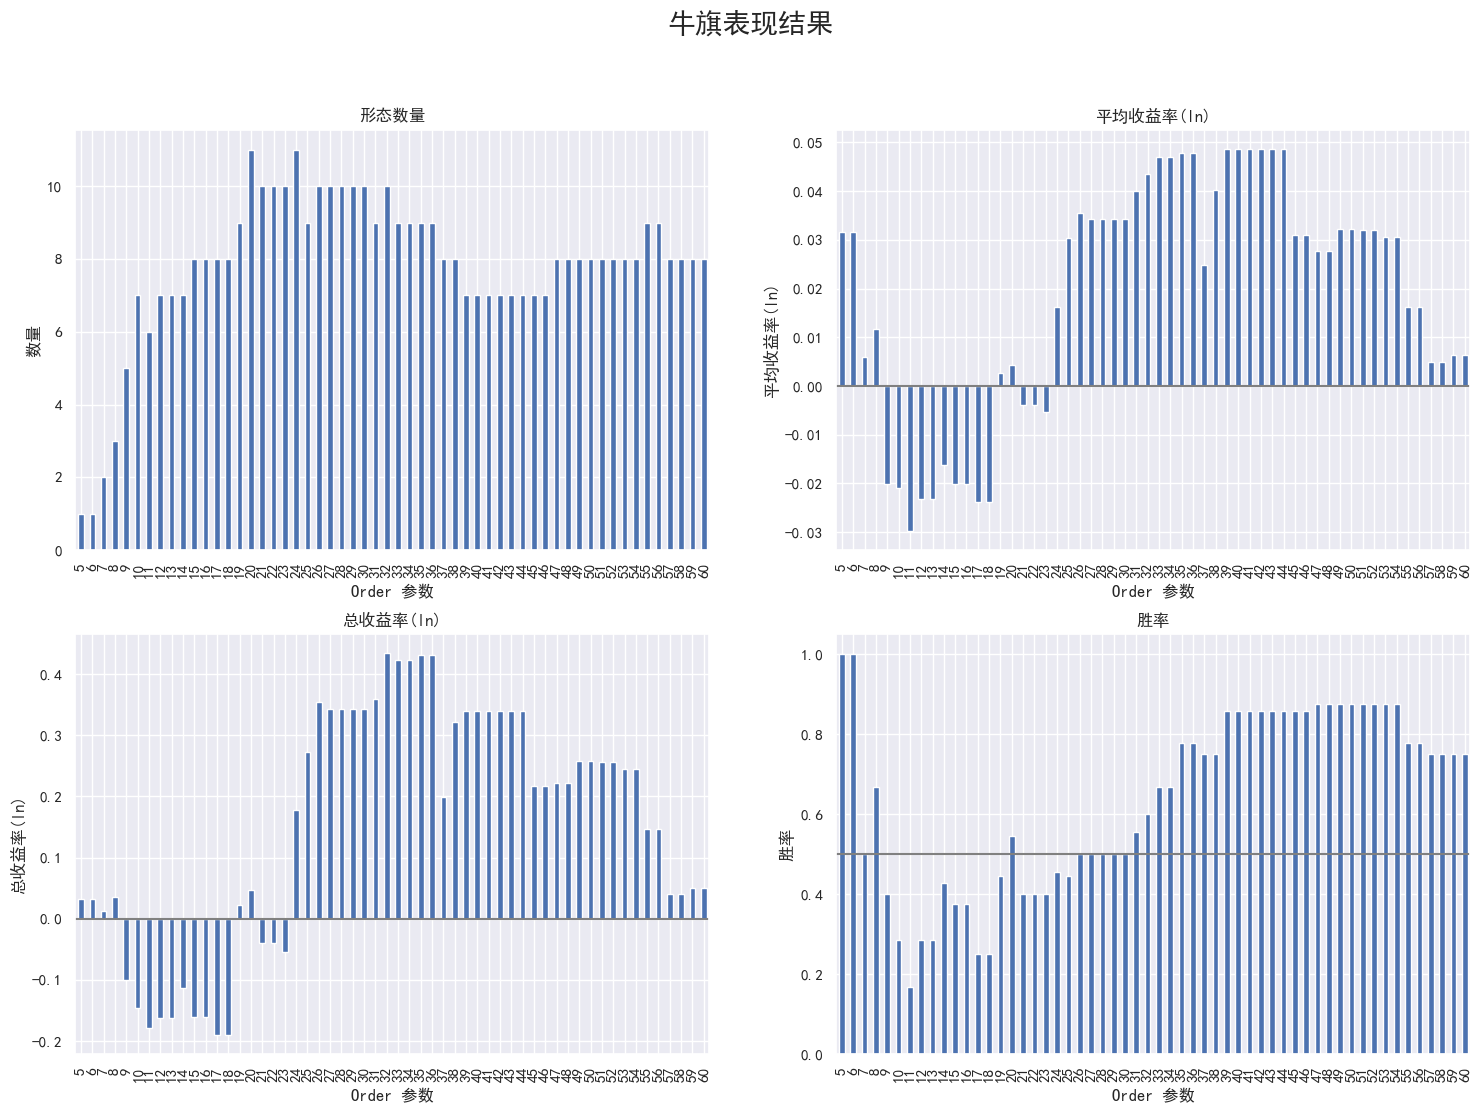

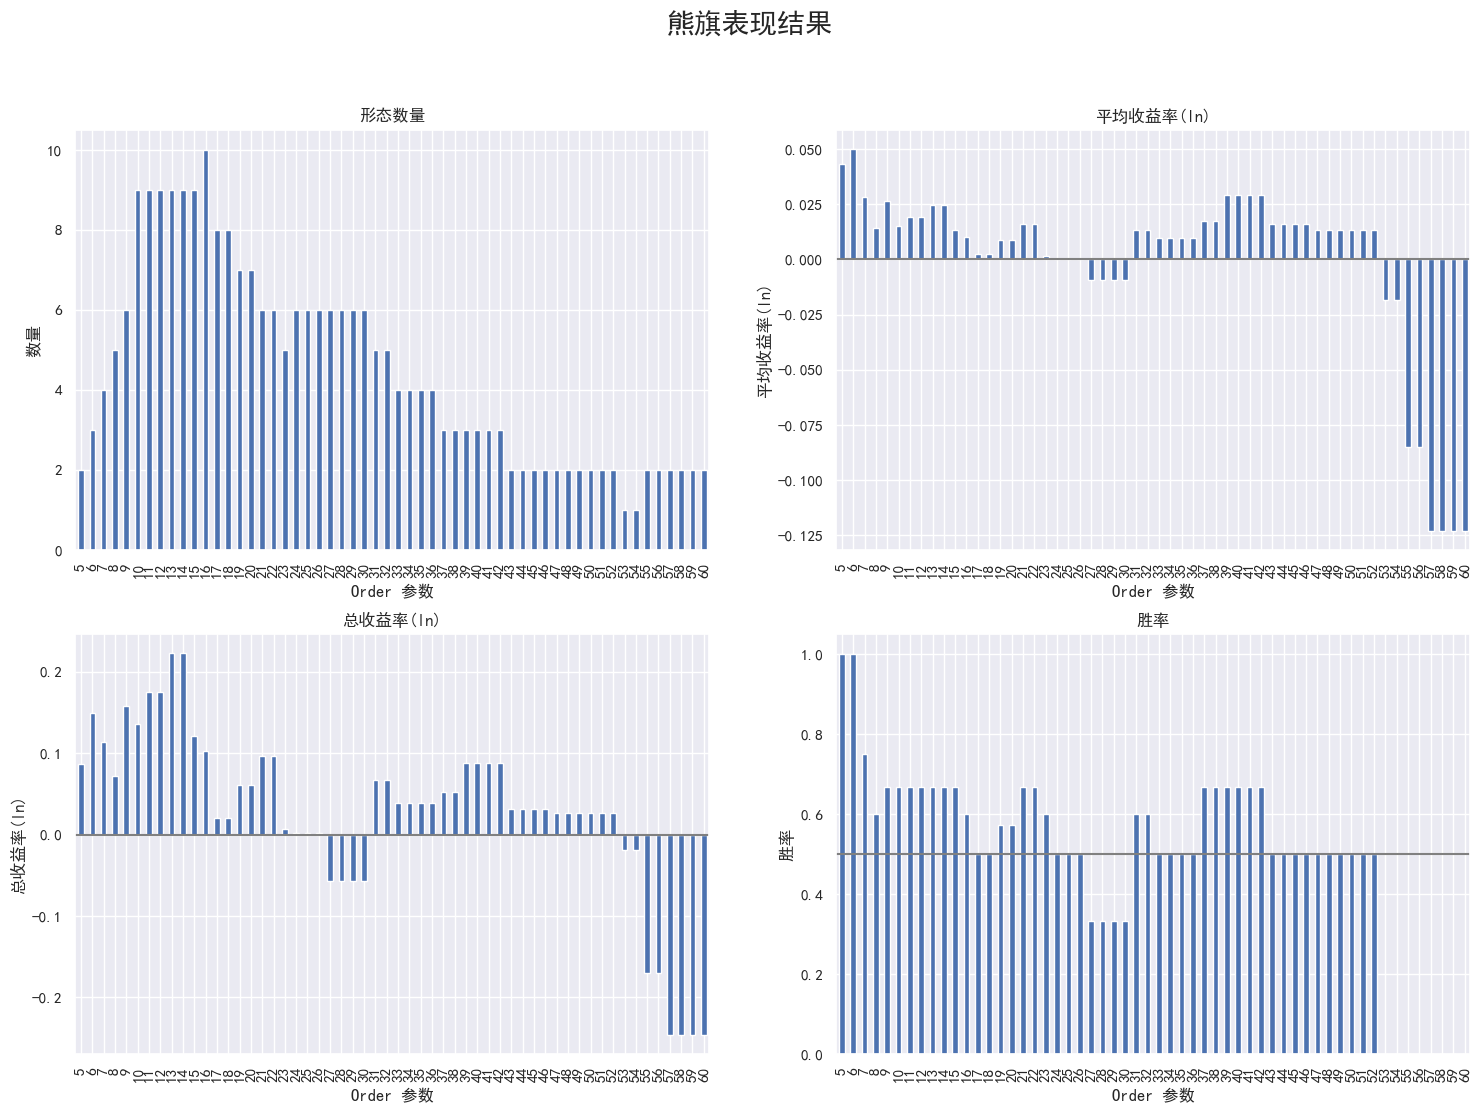

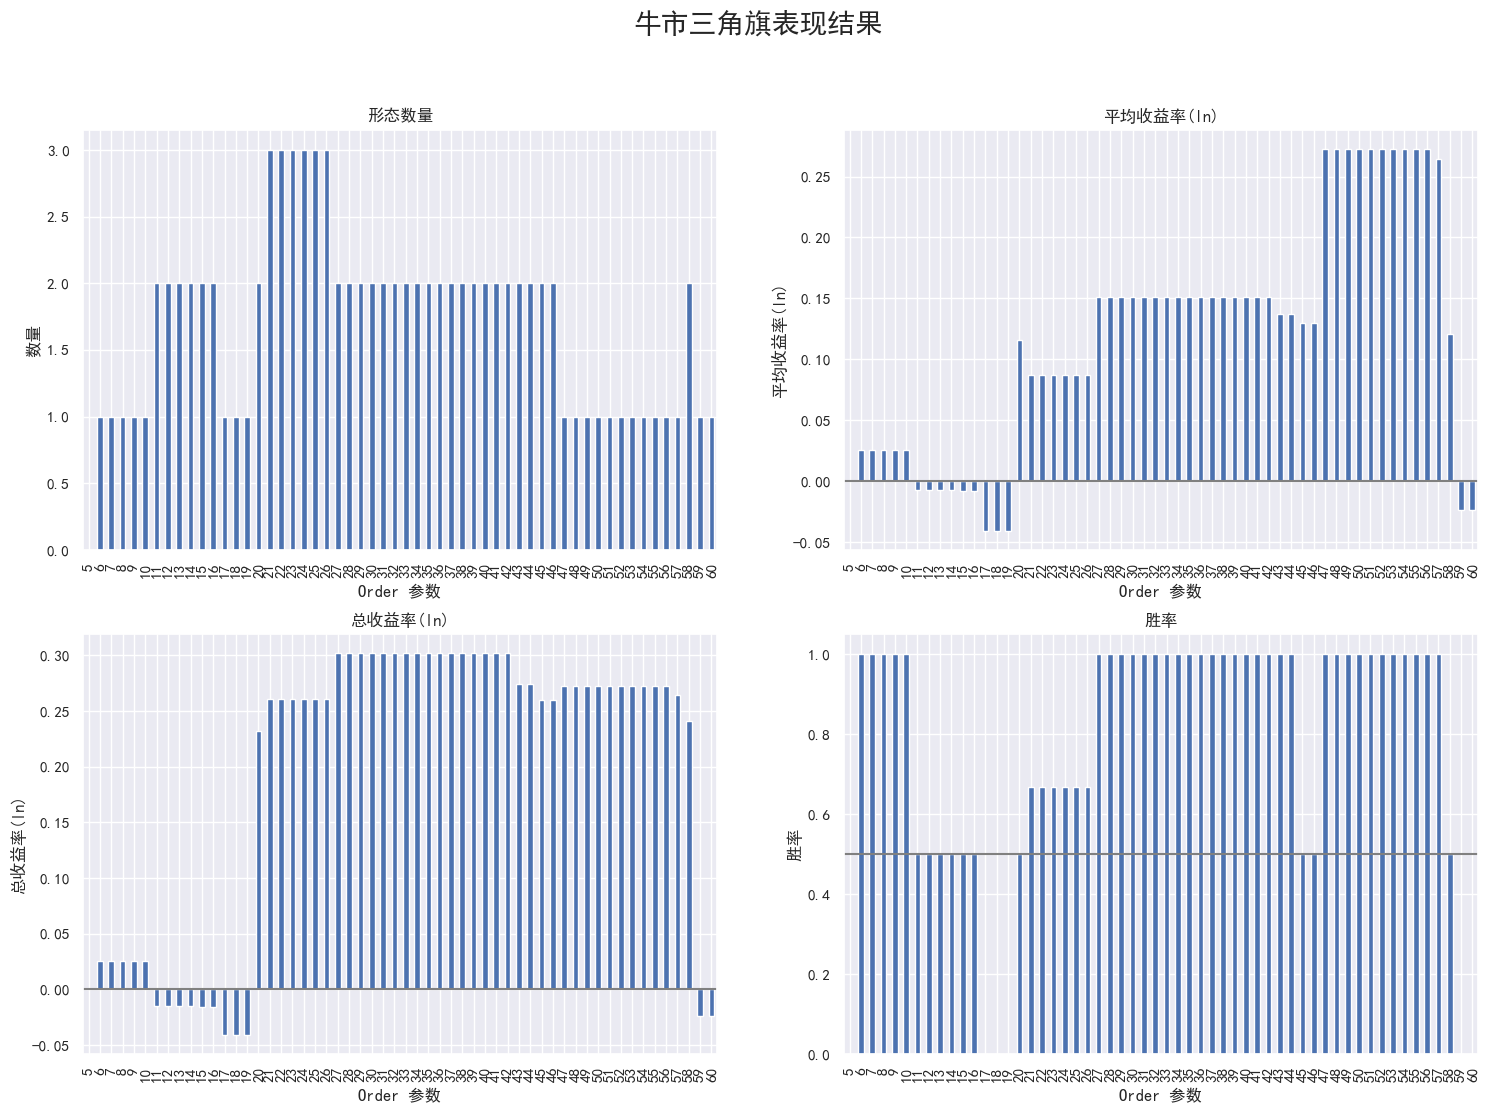

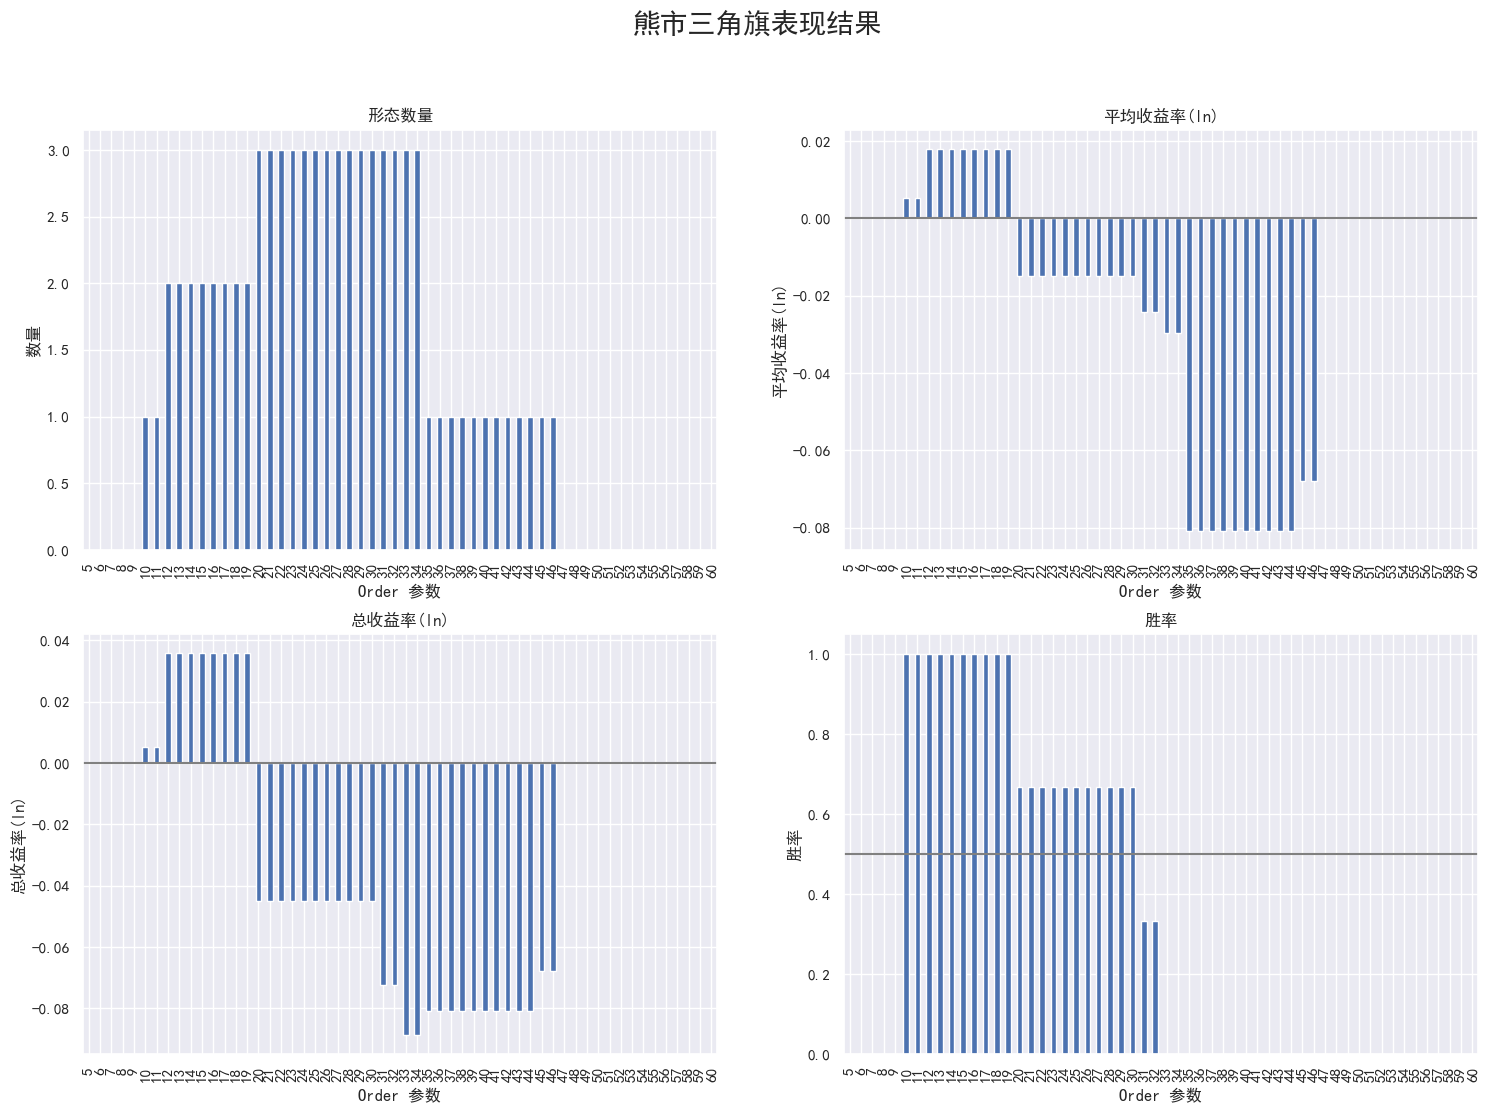

In [7]:
# 设置样式
sns.set_theme(style="darkgrid")
# sns.set_theme() 函数可以接受以下参数：
# context：控制绘图元素的比例，可选值有 "paper"、"notebook"、"talk"、"poster"，默认为 "notebook"
# style：控制绘图美学风格，可选值有 "darkgrid"、"whitegrid"、"dark"、"white"、"ticks"
# palette：控制颜色方案，可使用 Seaborn 内置调色板如 "deep"、"muted"、"bright" 等
# font：设置字体系列
# font_scale：字体大小的缩放因子
# color_codes：是否启用简短颜色代码
# rc：可传递字典覆盖默认的 matplotlib 参数

# sns.set_theme()与plt.style.use的区别：
# 1. sns.set_theme()是seaborn的新API，设置默认主题，包括颜色、网格等
# 2. plt.style.use直接使用Matplotlib的样式表，'seaborn-v0_8-bright'是保留的旧版seaborn风格
# sns.set_style("whitegrid")  # 设置网格样式

# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像时负号'-'显示为方块的问题

# plt.style.use('seaborn-v0_8-bright')  # 使用seaborn亮色主题
fig, ax = plt.subplots(2, 2, figsize=(18, 12))  # 创建2x2的子图，设置图表大小为18x12

fig.suptitle("牛旗表现结果", fontsize=20)  # 设置总标题

# 绘制牛市旗形的四个指标
results_df['bull_flag_count'].plot.bar(ax=ax[0,0])  # 形态数量柱状图
results_df['bull_flag_avg'].plot.bar(ax=ax[0,1])  # 平均收益柱状图
results_df['bull_flag_total'].plot.bar(ax=ax[1,0])  # 总收益柱状图
results_df['bull_flag_wr'].plot.bar(ax=ax[1,1])  # 胜率柱状图

# 添加参考线
ax[0,1].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 平均收益为0的参考线
ax[1,0].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 总收益为0的参考线
ax[1,1].hlines(0.5, xmin=-1, xmax=len(orders), color='gray')  # 胜率为50%的参考线

# 设置子图标题和标签
ax[0,0].set_title('形态数量')  # 形态数量子图标题
ax[0,0].set_xlabel('Order 参数')  # x轴标签
ax[0,0].set_ylabel('数量')  # y轴标签
ax[0,1].set_title('平均收益率(ln)')  # 平均收益子图标题
ax[0,1].set_xlabel('Order 参数')  # x轴标签
ax[0,1].set_ylabel('平均收益率(ln)')  # y轴标签
ax[1,0].set_title('总收益率(ln)')  # 总收益子图标题
ax[1,0].set_xlabel('Order 参数')  # x轴标签
ax[1,0].set_ylabel('总收益率(ln)')  # y轴标签
ax[1,1].set_title('胜率')  # 胜率子图标题
ax[1,1].set_xlabel('Order 参数')  # x轴标签
ax[1,1].set_ylabel('胜率')  # y轴标签




plt.show()  # 显示图表

# 绘制熊市旗形的性能图表
fig, ax = plt.subplots(2, 2, figsize=(18, 12))  # 创建2x2的子图，设置图表大小为18x12
fig.suptitle("熊旗表现结果", fontsize=20)  # 设置总标题

# 绘制熊市旗形的四个指标
results_df['bear_flag_count'].plot.bar(ax=ax[0,0])  # 形态数量柱状图
results_df['bear_flag_avg'].plot.bar(ax=ax[0,1])  # 平均收益柱状图
results_df['bear_flag_total'].plot.bar(ax=ax[1,0])  # 总收益柱状图
results_df['bear_flag_wr'].plot.bar(ax=ax[1,1])  # 胜率柱状图

# 添加参考线
ax[0,1].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 平均收益为0的参考线
ax[1,0].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 总收益为0的参考线
ax[1,1].hlines(0.5, xmin=-1, xmax=len(orders), color='gray')  # 胜率为50%的参考线

# 设置子图标题和标签
ax[0,0].set_title('形态数量')  # 形态数量子图标题
ax[0,0].set_xlabel('Order 参数')  # x轴标签
ax[0,0].set_ylabel('数量')  # y轴标签
ax[0,1].set_title('平均收益率(ln)')  # 平均收益子图标题
ax[0,1].set_xlabel('Order 参数')  # x轴标签
ax[0,1].set_ylabel('平均收益率(ln)')  # y轴标签
ax[1,0].set_title('总收益率(ln)')  # 总收益子图标题
ax[1,0].set_xlabel('Order 参数')  # x轴标签
ax[1,0].set_ylabel('总收益率(ln)')  # y轴标签
ax[1,1].set_title('胜率')  # 胜率子图标题
ax[1,1].set_xlabel('Order 参数')  # x轴标签
ax[1,1].set_ylabel('胜率')  # y轴标签

plt.show()  # 显示图表


# 绘制牛市三角旗的性能图表
fig, ax = plt.subplots(2, 2, figsize=(18, 12))  # 创建2x2的子图，设置图表大小为18x12
fig.suptitle("牛市三角旗表现结果", fontsize=20)  # 设置总标题

# 绘制牛市三角旗的四个指标
results_df['bull_pennant_count'].plot.bar(ax=ax[0,0])  # 形态数量柱状图
results_df['bull_pennant_avg'].plot.bar(ax=ax[0,1])  # 平均收益柱状图
results_df['bull_pennant_total'].plot.bar(ax=ax[1,0])  # 总收益柱状图
results_df['bull_pennant_wr'].plot.bar(ax=ax[1,1])  # 胜率柱状图

# 添加参考线
ax[0,1].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 平均收益为0的参考线
ax[1,0].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 总收益为0的参考线
ax[1,1].hlines(0.5, xmin=-1, xmax=len(orders), color='gray')  # 胜率为50%的参考线

# 设置子图标题和标签
ax[0,0].set_title('形态数量')  # 形态数量子图标题
ax[0,0].set_xlabel('Order 参数')  # x轴标签
ax[0,0].set_ylabel('数量')  # y轴标签
ax[0,1].set_title('平均收益率(ln)')  # 平均收益子图标题
ax[0,1].set_xlabel('Order 参数')  # x轴标签
ax[0,1].set_ylabel('平均收益率(ln)')  # y轴标签
ax[1,0].set_title('总收益率(ln)')  # 总收益子图标题
ax[1,0].set_xlabel('Order 参数')  # x轴标签
ax[1,0].set_ylabel('总收益率(ln)')  # y轴标签
ax[1,1].set_title('胜率')  # 胜率子图标题
ax[1,1].set_xlabel('Order 参数')  # x轴标签
ax[1,1].set_ylabel('胜率')  # y轴标签

plt.show()  # 显示图表

# 绘制熊市三角旗的性能图表
fig, ax = plt.subplots(2, 2, figsize=(18, 12))  # 创建2x2的子图，设置图表大小为18x12
fig.suptitle("熊市三角旗表现结果", fontsize=20)  # 设置总标题

# 绘制熊市三角旗的四个指标
results_df['bear_pennant_count'].plot.bar(ax=ax[0,0])  # 形态数量柱状图
results_df['bear_pennant_avg'].plot.bar(ax=ax[0,1])  # 平均收益柱状图
results_df['bear_pennant_total'].plot.bar(ax=ax[1,0])  # 总收益柱状图
results_df['bear_pennant_wr'].plot.bar(ax=ax[1,1])  # 胜率柱状图

# 添加参考线
ax[0,1].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 平均收益为0的参考线
ax[1,0].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 总收益为0的参考线
ax[1,1].hlines(0.5, xmin=-1, xmax=len(orders), color='gray')  # 胜率为50%的参考线

# 设置子图标题和标签
ax[0,0].set_title('形态数量')  # 形态数量子图标题
ax[0,0].set_xlabel('Order 参数')  # x轴标签
ax[0,0].set_ylabel('数量')  # y轴标签
ax[0,1].set_title('平均收益率(ln)')  # 平均收益子图标题
ax[0,1].set_xlabel('Order 参数')  # x轴标签
ax[0,1].set_ylabel('平均收益率(ln)')  # y轴标签
ax[1,0].set_title('总收益率(ln)')  # 总收益子图标题
ax[1,0].set_xlabel('Order 参数')  # x轴标签
ax[1,0].set_ylabel('总收益率(ln)')  # y轴标签
ax[1,1].set_title('胜率')  # 胜率子图标题
ax[1,1].set_xlabel('Order 参数')  # x轴标签
ax[1,1].set_ylabel('胜率')  # y轴标签

plt.show()  # 显示图表

In [10]:
import plotly.graph_objects as go
# 将所有orders参数的旗形绘制在同一图中
def plot_all_orders_flags(data, orders_list):
    """
    绘制不同order参数下识别出的所有旗形到同一个图表中
    
    参数:
    data: pd.DataFrame - K线数据
    orders_list: list - order参数列表
    """
    # 创建图表对象
    fig = go.Figure()
    
    # 添加收盘价线图
    fig.add_trace(go.Scatter(
        x=data.index,
        y=data['Close'],
        mode='lines',
        name='收盘价',
        line=dict(color='black', width=1)
    ))
    
    # 为不同order参数定义不同颜色
    colors = plt.cm.rainbow(np.linspace(0, 1, len(orders_list)))
    
    # 遍历每个order参数
    for i, order in enumerate(orders_list):
        # 使用当前order参数识别旗形
        bull_flags, bear_flags, bull_pennants, bear_pennants = find_flags_pennants_pips(data['Close'].to_numpy(), order,volume_data)
        
        # 合并所有类型的旗形
        all_patterns = bull_flags + bear_flags + bull_pennants + bear_pennants
        
        # 如果没有识别出旗形，继续下一个order
        if not all_patterns:
            continue
        
        # 为当前order参数的所有旗形添加标记
        for pattern in all_patterns:
            # 获取相对于显示范围的索引
            base_idx = data.index[pattern.base_x]
            tip_idx = data.index[pattern.tip_x]
            conf_idx = data.index[pattern.conf_x]
            
            # 添加旗杆线
            fig.add_trace(go.Scatter(
                x=[base_idx, tip_idx],
                y=[pattern.base_y, pattern.tip_y],
                mode='lines',
                line=dict(color=f'rgba({int(colors[i][0]*255)},{int(colors[i][1]*255)},{int(colors[i][2]*255)},1)', width=1),
                name=f'Order={order}',
                showlegend=False
            ))
            
            # 添加趋势线
            resist_y = [pattern.resist_intercept, 
                       pattern.resist_intercept + pattern.resist_slope * pattern.flag_width]
            support_y = [pattern.support_intercept,
                        pattern.support_intercept + pattern.support_slope * pattern.flag_width]
            
            fig.add_trace(go.Scatter(
                x=[tip_idx, conf_idx],
                y=[resist_y[0], resist_y[1]],
                mode='lines',
                line=dict(color=f'rgba({int(colors[i][0]*255)},{int(colors[i][1]*255)},{int(colors[i][2]*255)},1)', dash='dash'),
                showlegend=False
            ))
            
            fig.add_trace(go.Scatter(
                x=[tip_idx, conf_idx],
                y=[support_y[0], support_y[1]],
                mode='lines',
                line=dict(color=f'rgba({int(colors[i][0]*255)},{int(colors[i][1]*255)},{int(colors[i][2]*255)},1)', dash='dash'),
                showlegend=False
            ))
            
            # 添加关键点
            fig.add_trace(go.Scatter(
                x=[base_idx, tip_idx, conf_idx],
                y=[pattern.base_y, pattern.tip_y, pattern.conf_y],
                mode='markers',
                marker=dict(size=6, color=f'rgba({int(colors[i][0]*255)},{int(colors[i][1]*255)},{int(colors[i][2]*255)},1)'),
                name=f'Order={order}',
                showlegend=(pattern == all_patterns[0])  # 只为每个order显示一次图例
            ))
    
    # 更新图表布局
    fig.update_layout(
        template='plotly',
        xaxis_title='日期',
        yaxis_title='价格(对数)',
        showlegend=True,
        height=800,
        title='不同Order参数下的旗形识别结果对比'
    )
    
    # 添加范围滑块
    fig.update_xaxes(rangeslider_visible=True)
    
    return fig

# 使用函数绘制所有orders参数的旗形
orders = list(range(5, 51))
fig_all_orders = plot_all_orders_flags(data, orders)

# 使用plotly的显示方法而不是plt.show()
# fig_all_orders.show()

# 保存为HTML文件
fig_all_orders.write_html("不同Order参数下的旗形识别结果对比.html")

# 保存为图片格式
fig_all_orders.write_image("不同Order参数下的旗形识别结果对比.png", width=1600, height=900)

print("已生成不同Order参数下的旗形识别结果对比.html和不同Order参数下的旗形识别结果对比.png")


已生成不同Order参数下的旗形识别结果对比.html和不同Order参数下的旗形识别结果对比.png
